# NEU Steel Surface Defect Detection with YOLOv11s

Training **YOLOv11s** on the **NEU-DET** dataset (Roboflow YOLOv11 export).

**Dataset:** Train 1260 / Valid 360 / Test 179 images, 6 classes: `crazing, inclusion, patches, pitted_surface, rolled-in_scale, scratches` (exact class names depend on the Roboflow export).

**Why this notebook differs from a generic YOLO training script:**
- NEU images are **grayscale** (the 3 channels are identical) → hue & saturation augmentation are no-ops; only brightness (`hsv_v`) matters.
- Defect classes (crazing vs rolled-in scale vs pitted) are **texture-discriminated and visually similar** → avoid augmentations that destroy fine texture (heavy mosaic, mixup, copy-paste, blur).
- Defects often **cover a large fraction of the image** → strong mosaic shrinks them away; we lower it.
- Illumination/material variability is significant → **bump brightness aug**.
- Both horizontal and vertical flips are safe; steel-strip orientation isn't fixed.

**Pipeline:**
1. Setup
2. Dataset inspection (image counts, class distribution, bbox sizes, grayscale check, sample viz)
3. Augmentation tuned for NEU steel defects
4. Train YOLOv11s with early-stopping + target mAP@50 stop
5. Test-set evaluation + qualitative inference

## 1. Setup

In [1]:
!pip install -q ultralytics pyyaml matplotlib seaborn pandas opencv-python

In [2]:
import os
import glob
import yaml
import random
from pathlib import Path
from collections import Counter

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns

import torch
from ultralytics import YOLO

print('Torch:', torch.__version__, '| CUDA available:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))

random.seed(42); np.random.seed(42); torch.manual_seed(42)

Torch: 2.8.0+cu128 | CUDA available: True
GPU: Tesla T4


In [3]:
# ---- CONFIG ----
DATASET_DIR = Path('steel-defect')        # root from Roboflow export
DATA_YAML   = DATASET_DIR / 'data.yaml'

TRAIN_IMG_DIR = DATASET_DIR / 'train' / 'images'
TRAIN_LBL_DIR = DATASET_DIR / 'train' / 'labels'
VAL_IMG_DIR   = DATASET_DIR / 'valid' / 'images'
VAL_LBL_DIR   = DATASET_DIR / 'valid' / 'labels'
TEST_IMG_DIR  = DATASET_DIR / 'test'  / 'images'
TEST_LBL_DIR  = DATASET_DIR / 'test'  / 'labels'

assert DATA_YAML.exists(), f'data.yaml not found at {DATA_YAML}'
with open(DATA_YAML, 'r') as f:
    data_cfg = yaml.safe_load(f)
print('data.yaml contents:')
print(yaml.dump(data_cfg, sort_keys=False))

CLASS_NAMES = data_cfg['names'] if isinstance(data_cfg['names'], list) else list(data_cfg['names'].values())
NUM_CLASSES = len(CLASS_NAMES)
print(f'Classes ({NUM_CLASSES}):', CLASS_NAMES)

data.yaml contents:
train: ../train/images
val: ../valid/images
test: ../test/images
nc: 6
names:
- crazing
- inclusion
- patches
- pitted_surface
- rolled-in_scale
- scratches
roboflow:
  workspace: neudatasetoriginal
  project: neu-steel-defect-dataset
  version: 1
  license: CC BY 4.0
  url: https://universe.roboflow.com/neudatasetoriginal/neu-steel-defect-dataset/dataset/1

Classes (6): ['crazing', 'inclusion', 'patches', 'pitted_surface', 'rolled-in_scale', 'scratches']


## 2. Dataset Inspection

Image counts: {'train': 1260, 'valid': 360, 'test': 179}


/tmp/ipykernel_3428/2462322029.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(split_counts.keys()), y=list(split_counts.values()), palette='mako')


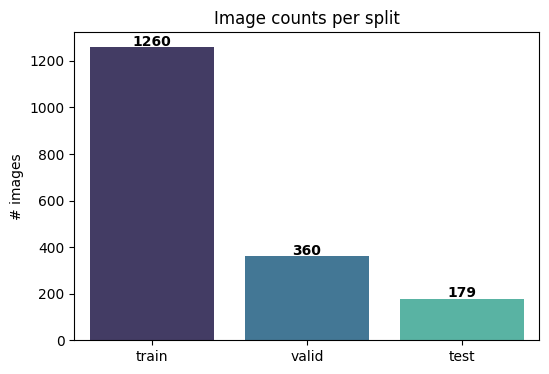

In [4]:
def count_imgs(p):
    return len(glob.glob(str(p / '*.jpg'))) + len(glob.glob(str(p / '*.png'))) + len(glob.glob(str(p / '*.jpeg')))

split_counts = {
    'train': count_imgs(TRAIN_IMG_DIR),
    'valid': count_imgs(VAL_IMG_DIR),
    'test':  count_imgs(TEST_IMG_DIR),
}
print('Image counts:', split_counts)

plt.figure(figsize=(6, 4))
sns.barplot(x=list(split_counts.keys()), y=list(split_counts.values()), palette='mako')
plt.title('Image counts per split'); plt.ylabel('# images')
for i, v in enumerate(split_counts.values()):
    plt.text(i, v + 5, str(v), ha='center', fontweight='bold')
plt.show()

In [5]:
# Confirm images are grayscale (this drives the HSV augmentation choices below)
sample_files = (sorted(glob.glob(str(TRAIN_IMG_DIR / '*.jpg'))) +
                sorted(glob.glob(str(TRAIN_IMG_DIR / '*.png'))))[:30]
gray_like = 0
for fp in sample_files:
    img = cv2.imread(fp)
    b, g, r = cv2.split(img)
    if np.allclose(b, g, atol=2) and np.allclose(g, r, atol=2):
        gray_like += 1
print(f'Of {len(sample_files)} sampled training images, {gray_like} are grayscale (R==G==B).')
IS_GRAYSCALE = gray_like / max(1, len(sample_files)) > 0.9
print('Treating dataset as grayscale:', IS_GRAYSCALE)

# Also check image resolution after Roboflow's resize
img = cv2.imread(sample_files[0])
print('Sample image shape:', img.shape)

Of 30 sampled training images, 30 are grayscale (R==G==B).
Treating dataset as grayscale: True
Sample image shape: (640, 640, 3)


             class  train  valid  test
0          crazing    454    165    70
1        inclusion    701    175   135
2          patches    634    169    75
3   pitted_surface    319     80    33
4  rolled-in_scale    440    128    60
5        scratches    383    117    48


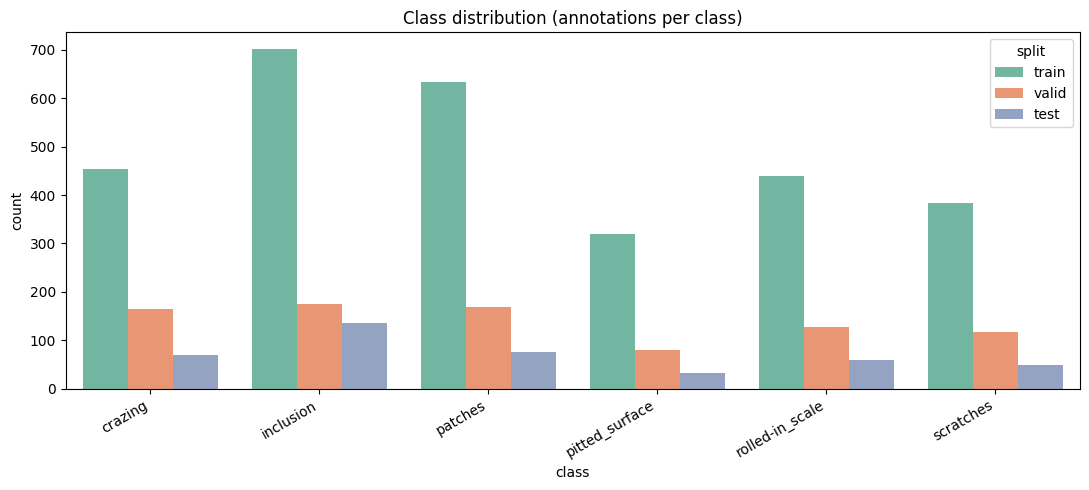

In [6]:
# Per-class annotation counts
def collect_class_counts(label_dir):
    counts = Counter()
    for lbl in glob.glob(str(label_dir / '*.txt')):
        with open(lbl, 'r') as f:
            for line in f:
                parts = line.strip().split()
                if not parts: continue
                counts[int(parts[0])] += 1
    return counts

train_counts = collect_class_counts(TRAIN_LBL_DIR)
val_counts   = collect_class_counts(VAL_LBL_DIR)
test_counts  = collect_class_counts(TEST_LBL_DIR)

df = pd.DataFrame({
    'class': [CLASS_NAMES[i] for i in range(NUM_CLASSES)],
    'train': [train_counts.get(i, 0) for i in range(NUM_CLASSES)],
    'valid': [val_counts.get(i, 0)   for i in range(NUM_CLASSES)],
    'test':  [test_counts.get(i, 0)  for i in range(NUM_CLASSES)],
})
print(df)

df_m = df.melt(id_vars='class', var_name='split', value_name='count')
plt.figure(figsize=(11, 5))
sns.barplot(data=df_m, x='class', y='count', hue='split', palette='Set2')
plt.title('Class distribution (annotations per class)')
plt.xticks(rotation=30, ha='right'); plt.tight_layout(); plt.show()

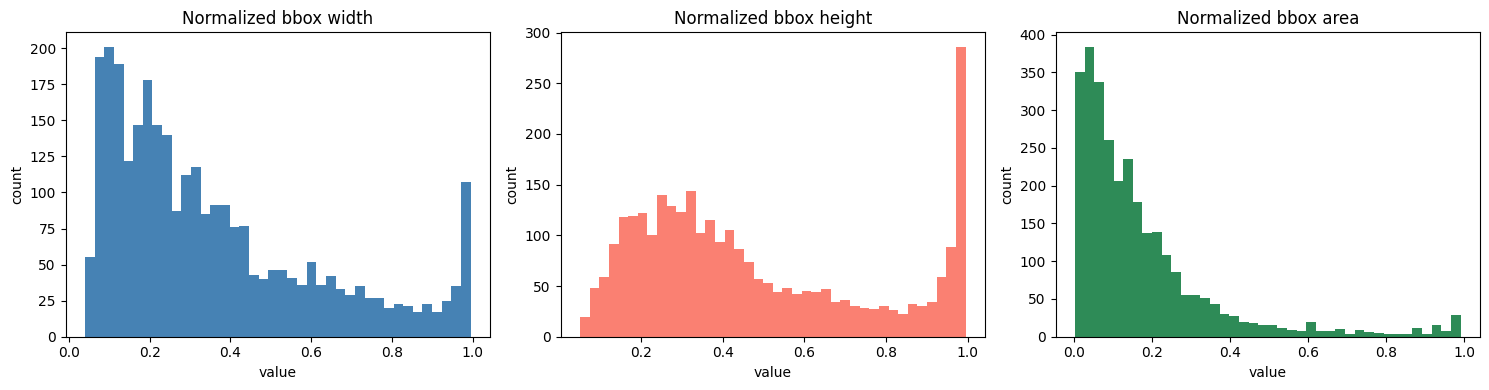

Median bbox area: 0.1166
  -> For NEU steel this is typically LARGE (often > 0.1).
  -> Implication: strong mosaic (1.0) shrinks defects too much. Use ~0.5.


In [7]:
# Bbox size distribution — for NEU steel, many defects are LARGE (fill most of the image)
def collect_bbox_sizes(label_dir):
    ws, hs, areas = [], [], []
    for lbl in glob.glob(str(label_dir / '*.txt')):
        with open(lbl, 'r') as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) < 5: continue
                w, h = float(parts[3]), float(parts[4])
                ws.append(w); hs.append(h); areas.append(w * h)
    return np.array(ws), np.array(hs), np.array(areas)

ws, hs, areas = collect_bbox_sizes(TRAIN_LBL_DIR)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].hist(ws, bins=40, color='steelblue');  axes[0].set_title('Normalized bbox width')
axes[1].hist(hs, bins=40, color='salmon');     axes[1].set_title('Normalized bbox height')
axes[2].hist(areas, bins=40, color='seagreen');axes[2].set_title('Normalized bbox area')
for ax in axes: ax.set_xlabel('value'); ax.set_ylabel('count')
plt.tight_layout(); plt.show()

print(f'Median bbox area: {np.median(areas):.4f}')
print(f'  -> For NEU steel this is typically LARGE (often > 0.1).')
print(f'  -> Implication: strong mosaic (1.0) shrinks defects too much. Use ~0.5.')

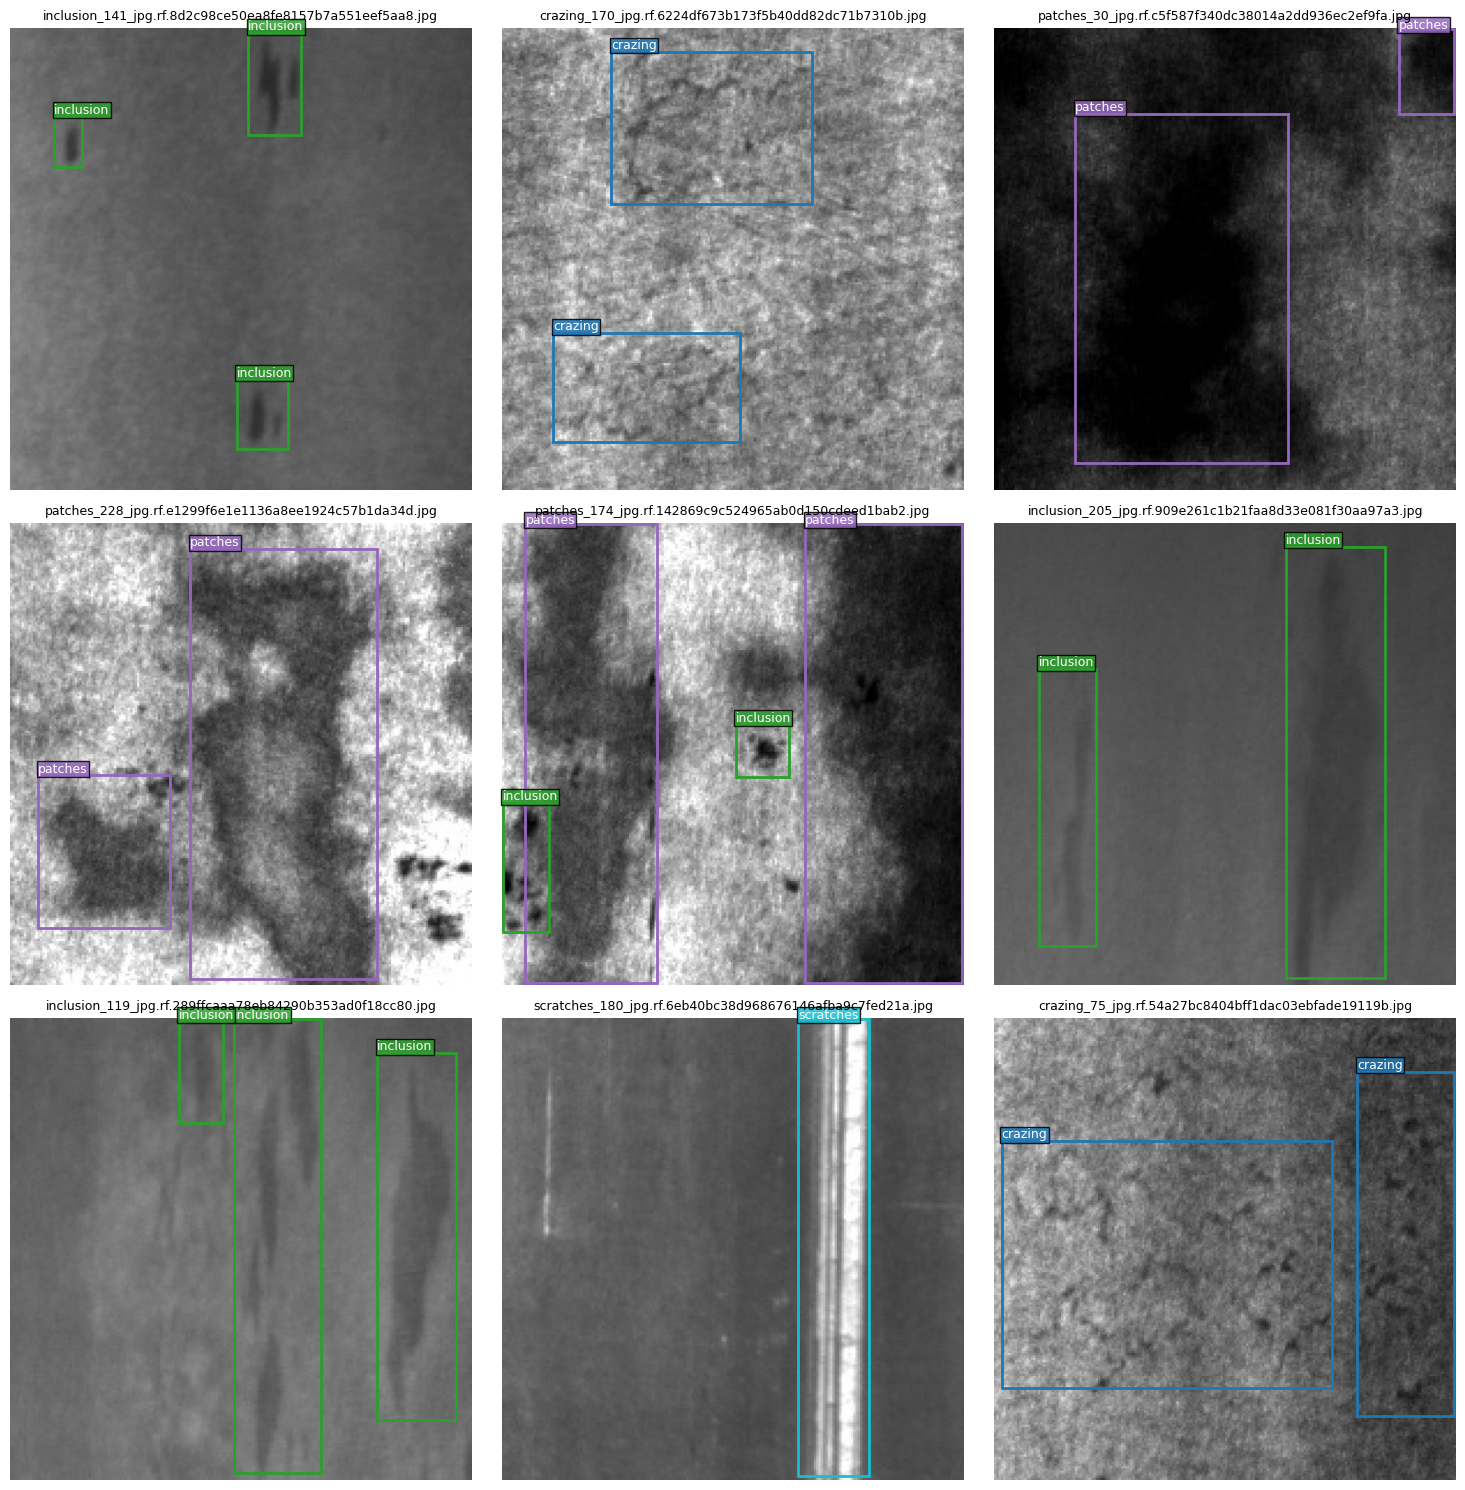

In [8]:
# Visualize sample images with bounding boxes
def yolo_to_xyxy(box, W, H):
    cx, cy, w, h = box
    return (cx - w/2)*W, (cy - h/2)*H, (cx + w/2)*W, (cy + h/2)*H

def show_sample(img_dir, lbl_dir, n=9):
    files = sorted(glob.glob(str(img_dir / '*.jpg')) + glob.glob(str(img_dir / '*.png')))
    sample = random.sample(files, min(n, len(files)))
    cols = 3; rows = (len(sample) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(cols*5, rows*5))
    axes = np.array(axes).reshape(-1)
    colors = plt.cm.tab10(np.linspace(0, 1, NUM_CLASSES))
    for ax, img_path in zip(axes, sample):
        img = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
        H, W = img.shape[:2]; ax.imshow(img, cmap='gray' if IS_GRAYSCALE else None)
        lbl_path = Path(lbl_dir) / (Path(img_path).stem + '.txt')
        if lbl_path.exists():
            with open(lbl_path) as f:
                for line in f:
                    parts = line.strip().split()
                    if len(parts) < 5: continue
                    cls = int(parts[0])
                    x1, y1, x2, y2 = yolo_to_xyxy(list(map(float, parts[1:5])), W, H)
                    ax.add_patch(patches.Rectangle((x1, y1), x2-x1, y2-y1, linewidth=2,
                                                   edgecolor=colors[cls % NUM_CLASSES], facecolor='none'))
                    ax.text(x1, max(y1-4, 0), CLASS_NAMES[cls], color='white', fontsize=9,
                            bbox=dict(facecolor=colors[cls % NUM_CLASSES], alpha=0.85, pad=1))
        ax.set_title(Path(img_path).name, fontsize=9); ax.axis('off')
    for ax in axes[len(sample):]: ax.axis('off')
    plt.tight_layout(); plt.show()

show_sample(TRAIN_IMG_DIR, TRAIN_LBL_DIR, n=9)

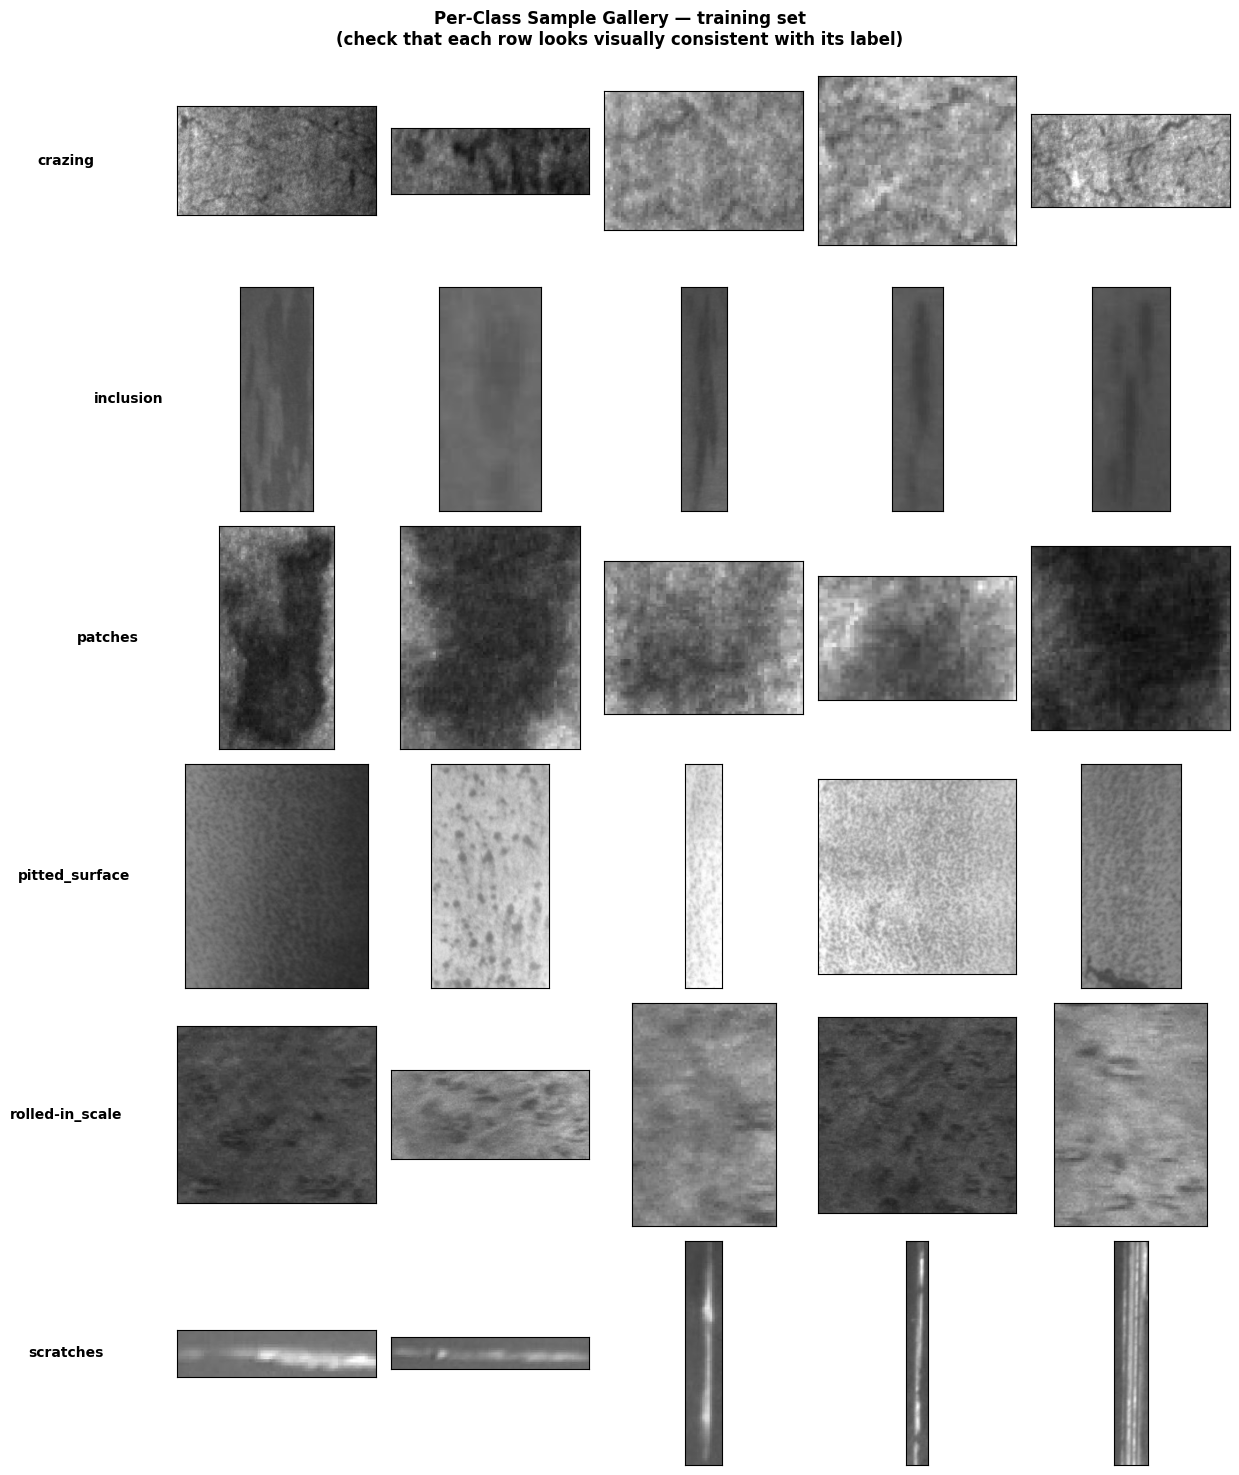

In [10]:
# --- EDA 1: Per-class sample gallery ---
# CRITICAL for NEU: 6 classes (crazing, pitted_surface, rolled-in_scale, etc.)
# look visually similar — this gallery confirms labels are correct before training

def show_class_gallery(img_dir, lbl_dir, class_names, n_per_class=5):
    class_samples = {i: [] for i in range(len(class_names))}
    for lbl_path in glob.glob(str(lbl_dir / '*.txt')):
        img_path = img_dir / (Path(lbl_path).stem + '.jpg')
        if not img_path.exists():
            img_path = img_dir / (Path(lbl_path).stem + '.png')
        if not img_path.exists():
            continue
        img = cv2.cvtColor(cv2.imread(str(img_path)), cv2.COLOR_BGR2RGB)
        H, W = img.shape[:2]
        with open(lbl_path) as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) < 5:
                    continue
                cls = int(parts[0])
                cx, cy, w, h = map(float, parts[1:5])
                x1 = max(0, int((cx - w / 2) * W))
                y1 = max(0, int((cy - h / 2) * H))
                x2 = min(W, int((cx + w / 2) * W))
                y2 = min(H, int((cy + h / 2) * H))
                crop = img[y1:y2, x1:x2]
                if crop.size == 0:
                    continue
                if len(class_samples[cls]) < n_per_class:
                    class_samples[cls].append(crop)

    n_classes = len(class_names)
    fig, axes = plt.subplots(n_classes, n_per_class, figsize=(n_per_class * 2.5, n_classes * 2.5))
    if n_classes == 1:
        axes = [axes]
    for r, (cls_id, crops) in enumerate(class_samples.items()):
        for c in range(n_per_class):
            ax = axes[r][c]
            if c < len(crops):
                ax.imshow(crops[c], cmap='gray' if IS_GRAYSCALE else None)
            else:
                ax.set_facecolor('#111')
            if c == 0:
                ax.set_ylabel(class_names[cls_id], fontsize=10, fontweight='bold',
                              rotation=0, labelpad=80, va='center')
            ax.set_xticks([]); ax.set_yticks([])
    plt.suptitle('Per-Class Sample Gallery — training set\n'
                 '(check that each row looks visually consistent with its label)',
                 fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

show_class_gallery(TRAIN_IMG_DIR, TRAIN_LBL_DIR, CLASS_NAMES, n_per_class=5)

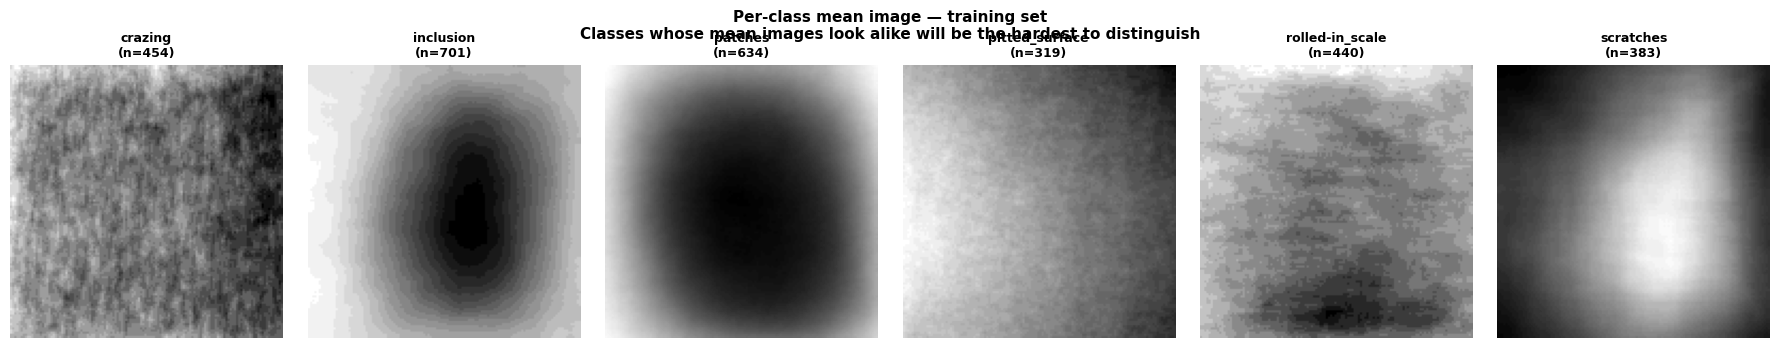

In [11]:
# --- EDA 2: Per-class mean image (★ steel-specific) ---
# Averages all training crops per class.
# If two class means look nearly identical, those classes will be the hardest to separate
# and you should monitor their per-class mAP closely during training.

def compute_class_mean_images(img_dir, lbl_dir, class_names, target_size=(128, 128)):
    accumulators = {i: np.zeros((*target_size, 3), dtype=np.float64)
                    for i in range(len(class_names))}
    counts = {i: 0 for i in range(len(class_names))}

    for lbl_path in glob.glob(str(lbl_dir / '*.txt')):
        img_path = img_dir / (Path(lbl_path).stem + '.jpg')
        if not img_path.exists():
            img_path = img_dir / (Path(lbl_path).stem + '.png')
        if not img_path.exists():
            continue
        img = cv2.cvtColor(cv2.imread(str(img_path)), cv2.COLOR_BGR2RGB)
        H, W = img.shape[:2]
        with open(lbl_path) as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) < 5:
                    continue
                cls = int(parts[0])
                cx, cy, w, h = map(float, parts[1:5])
                x1 = max(0, int((cx - w / 2) * W))
                y1 = max(0, int((cy - h / 2) * H))
                x2 = min(W, int((cx + w / 2) * W))
                y2 = min(H, int((cy + h / 2) * H))
                crop = img[y1:y2, x1:x2]
                if crop.size == 0:
                    continue
                crop_resized = cv2.resize(crop, target_size[::-1])
                accumulators[cls] += crop_resized.astype(np.float64)
                counts[cls] += 1

    mean_imgs = {}
    for cls_id in range(len(class_names)):
        if counts[cls_id] > 0:
            mean_imgs[cls_id] = (accumulators[cls_id] / counts[cls_id]).astype(np.uint8)
    return mean_imgs, counts

mean_imgs, ann_counts = compute_class_mean_images(TRAIN_IMG_DIR, TRAIN_LBL_DIR, CLASS_NAMES)

fig, axes = plt.subplots(1, NUM_CLASSES, figsize=(NUM_CLASSES * 3, 3.5))
if NUM_CLASSES == 1:
    axes = [axes]
for i, ax in enumerate(axes):
    if i in mean_imgs:
        img_show = cv2.cvtColor(mean_imgs[i], cv2.COLOR_RGB2GRAY) if IS_GRAYSCALE else mean_imgs[i]
        ax.imshow(img_show, cmap='gray' if IS_GRAYSCALE else None)
        ax.set_title(f'{CLASS_NAMES[i]}\n(n={ann_counts[i]})', fontsize=9, fontweight='bold')
    else:
        ax.set_facecolor('#111')
        ax.set_title(f'{CLASS_NAMES[i]}\n(no samples)', fontsize=9)
    ax.axis('off')

plt.suptitle('Per-class mean image — training set\n'
             'Classes whose mean images look alike will be the hardest to distinguish',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

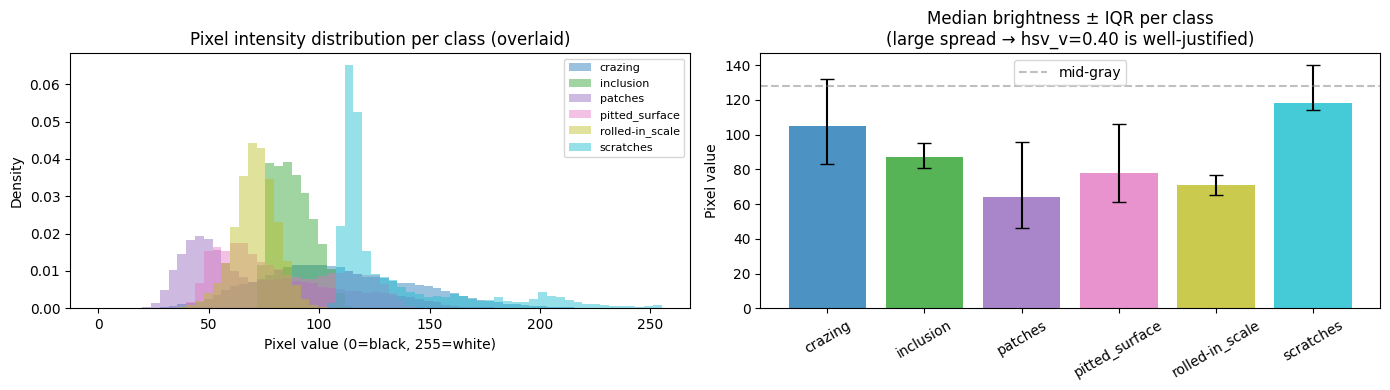

Class brightness summary:
               crazing: median=105.0  IQR=[83.0, 132.0]
             inclusion: median=87.0  IQR=[81.0, 95.0]
               patches: median=64.0  IQR=[46.0, 96.0]
        pitted_surface: median=78.0  IQR=[61.0, 106.0]
       rolled-in_scale: median=71.0  IQR=[65.0, 77.0]
             scratches: median=118.0  IQR=[114.0, 140.0]


In [17]:
# --- EDA 3: Pixel intensity distribution per class (★ steel-specific) ---

def collect_brightness_per_class(img_dir, lbl_dir, class_names, max_crops=200):
    class_pixels = {i: [] for i in range(len(class_names))}
    for lbl_path in glob.glob(str(lbl_dir / '*.txt')):
        img_path = img_dir / (Path(lbl_path).stem + '.jpg')
        if not img_path.exists():
            img_path = img_dir / (Path(lbl_path).stem + '.png')
        if not img_path.exists():
            continue
        img_gray = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
        H, W = img_gray.shape
        with open(lbl_path) as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) < 5:
                    continue
                cls = int(parts[0])
                if len(class_pixels[cls]) >= max_crops:
                    continue
                cx, cy, w, h = map(float, parts[1:5])
                x1 = max(0, int((cx - w / 2) * W))
                y1 = max(0, int((cy - h / 2) * H))
                x2 = min(W, int((cx + w / 2) * W))
                y2 = min(H, int((cy + h / 2) * H))
                crop = img_gray[y1:y2, x1:x2]
                if crop.size == 0:
                    continue
                class_pixels[cls].extend(crop.flatten().tolist())
    return class_pixels

class_pixels = collect_brightness_per_class(TRAIN_IMG_DIR, TRAIN_LBL_DIR, CLASS_NAMES)

colors = plt.cm.tab10(np.linspace(0, 1, NUM_CLASSES))
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for i, color in enumerate(colors):
    px = class_pixels[i]
    if px:
        axes[0].hist(px, bins=64, range=(0, 255), alpha=0.45,
                     label=CLASS_NAMES[i], color=color, density=True)
axes[0].set_title('Pixel intensity distribution per class (overlaid)')
axes[0].set_xlabel('Pixel value (0=black, 255=white)')
axes[0].set_ylabel('Density')
axes[0].legend(fontsize=8)

medians = np.array([np.median(class_pixels[i]) if class_pixels[i] else 0
                    for i in range(NUM_CLASSES)])
q25     = np.array([np.percentile(class_pixels[i], 25) if class_pixels[i] else 0
                    for i in range(NUM_CLASSES)])
q75     = np.array([np.percentile(class_pixels[i], 75) if class_pixels[i] else 0
                    for i in range(NUM_CLASSES)])

# FIX: compute errors as numpy ops — no zip argument confusion
yerr = [medians - q25,   # lower bar: median - Q25  (always >= 0)
        q75 - medians]   # upper bar: Q75 - median  (always >= 0)

axes[1].bar(CLASS_NAMES, medians, yerr=yerr, color=colors, capsize=5, alpha=0.8)
axes[1].set_title('Median brightness ± IQR per class\n(large spread → hsv_v=0.40 is well-justified)')
axes[1].set_ylabel('Pixel value')
axes[1].tick_params(axis='x', rotation=30)
axes[1].axhline(128, color='gray', linestyle='--', alpha=0.5, label='mid-gray')
axes[1].legend()

plt.tight_layout()
plt.show()

print('Class brightness summary:')
for i in range(NUM_CLASSES):
    px = class_pixels[i]
    if px:
        print(f'  {CLASS_NAMES[i]:>20}: median={np.median(px):.1f}  '
              f'IQR=[{np.percentile(px,25):.1f}, {np.percentile(px,75):.1f}]')

Aspect ratio (w/h) summary per class:
               crazing: median=1.804  range=[0.21, 6.19]  n=454
             inclusion: median=0.362  range=[0.11, 5.10]  n=701
               patches: median=0.717  range=[0.19, 3.58]  n=634
        pitted_surface: median=0.737  range=[0.14, 2.75]  n=319
       rolled-in_scale: median=0.965  range=[0.28, 4.58]  n=440
             scratches: median=0.179  range=[0.05, 18.10]  n=383


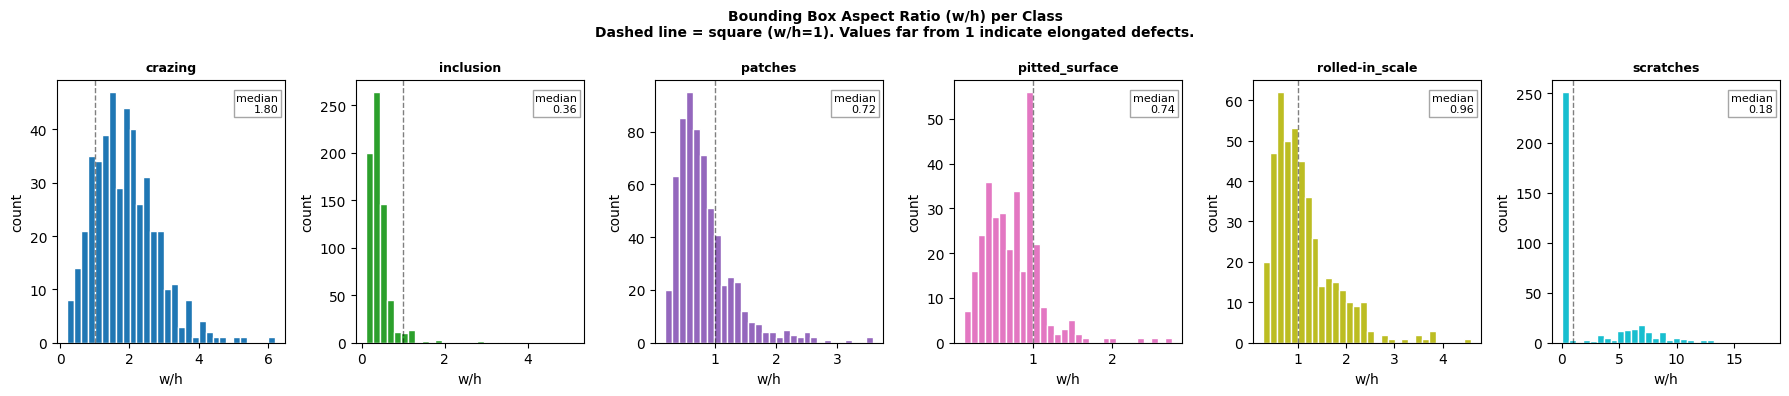

In [14]:
# --- EDA 4: Bounding-box aspect ratio per class ---
# Scratches → high w/h or low w/h (elongated)
# Crazing / pitted_surface / patches → near-square (w/h ≈ 1)
# This informs whether any class benefits from rectangular anchor priors

def collect_aspect_ratios_by_class(label_dir, n_classes):
    ratios = {i: [] for i in range(n_classes)}
    for lbl in glob.glob(str(label_dir / '*.txt')):
        with open(lbl) as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) < 5:
                    continue
                cls = int(parts[0])
                w, h = float(parts[3]), float(parts[4])
                if h > 0:
                    ratios[cls].append(w / h)
    return ratios

aspect_ratios = collect_aspect_ratios_by_class(TRAIN_LBL_DIR, NUM_CLASSES)

fig, axes = plt.subplots(1, NUM_CLASSES, figsize=(NUM_CLASSES * 3, 4), sharey=False)
if NUM_CLASSES == 1:
    axes = [axes]
colors = plt.cm.tab10(np.linspace(0, 1, NUM_CLASSES))

print('Aspect ratio (w/h) summary per class:')
for i, (ax, color) in enumerate(zip(axes, colors)):
    data = aspect_ratios[i]
    if data:
        ax.hist(data, bins=30, color=color, edgecolor='white')
        ax.axvline(1.0, color='black', linestyle='--', alpha=0.5, linewidth=1)
        ax.set_title(CLASS_NAMES[i], fontsize=9, fontweight='bold')
        ax.set_xlabel('w/h')
        ax.set_ylabel('count')
        median_r = np.median(data)
        ax.text(0.97, 0.95, f'median\n{median_r:.2f}',
                transform=ax.transAxes, ha='right', va='top',
                fontsize=8, color='black',
                bbox=dict(facecolor='white', alpha=0.7, edgecolor='gray', pad=2))
        print(f'  {CLASS_NAMES[i]:>20}: median={median_r:.3f}  '
              f'range=[{min(data):.2f}, {max(data):.2f}]  n={len(data)}')
    else:
        ax.text(0.5, 0.5, 'No data', ha='center', va='center', transform=ax.transAxes)

plt.suptitle('Bounding Box Aspect Ratio (w/h) per Class\n'
             'Dashed line = square (w/h=1). Values far from 1 indicate elongated defects.',
             fontweight='bold', fontsize=10)
plt.tight_layout()
plt.show()

Train: mean=2.33, median=2.0, max=9, zero-label images=0
Val: mean=2.32, median=2.0, max=9, zero-label images=0


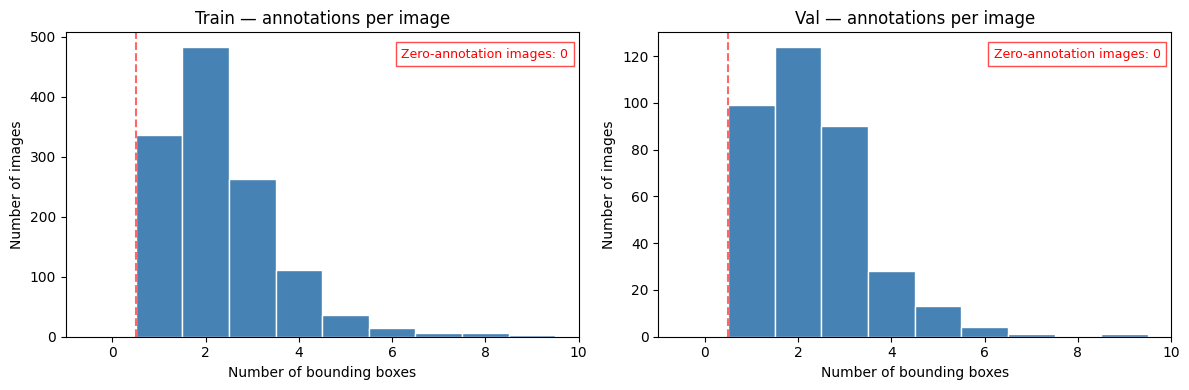

In [15]:
# --- EDA 5: Annotations-per-image distribution ---
# NEU steel images typically have ONE defect type per image.
# Images with zero annotations are background images — too many can hurt recall.
# Images with many annotations may be mislabelled or over-annotated.

def annotations_per_image(label_dir):
    counts = []
    for lbl in glob.glob(str(label_dir / '*.txt')):
        with open(lbl) as f:
            lines = [l for l in f if l.strip()]
        counts.append(len(lines))
    return counts

train_ann = annotations_per_image(TRAIN_LBL_DIR)
val_ann   = annotations_per_image(VAL_LBL_DIR)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, counts, split in zip(axes, [train_ann, val_ann], ['Train', 'Val']):
    ax.hist(counts, bins=range(0, max(counts) + 2), color='steelblue',
            edgecolor='white', align='left')
    ax.set_title(f'{split} — annotations per image')
    ax.set_xlabel('Number of bounding boxes'); ax.set_ylabel('Number of images')
    zero_count = counts.count(0)
    ax.axvline(0.5, color='red', linestyle='--', alpha=0.6)
    ax.text(0.98, 0.95, f'Zero-annotation images: {zero_count}',
            transform=ax.transAxes, ha='right', va='top', color='red', fontsize=9,
            bbox=dict(facecolor='white', alpha=0.7, edgecolor='red'))
    print(f'{split}: mean={np.mean(counts):.2f}, median={np.median(counts):.1f}, '
          f'max={max(counts)}, zero-label images={zero_count}')
plt.tight_layout()
plt.show()

In [16]:
# --- EDA 6: Label sanity check ---
# Catches malformed lines, out-of-range class IDs, zero-size boxes, missing images.
# These issues are silent — they don't raise errors but degrade training quality.

def label_sanity_check(label_dir, img_dir, n_classes):
    issues = []
    total = 0
    for lbl_path in glob.glob(str(label_dir / '*.txt')):
        total += 1
        stem = Path(lbl_path).stem
        img_exists = any((img_dir / f'{stem}{ext}').exists()
                         for ext in ['.jpg', '.png', '.jpeg'])
        if not img_exists:
            issues.append({'file': stem, 'issue': 'missing image'})
        with open(lbl_path) as f:
            lines = [l.strip() for l in f if l.strip()]
        if not lines:
            issues.append({'file': stem, 'issue': 'zero annotations'})
            continue
        for line in lines:
            parts = line.split()
            if len(parts) < 5:
                issues.append({'file': stem, 'issue': f'malformed line: "{line}"'})
                continue
            try:
                cls = int(parts[0])
                cx, cy, w, h = map(float, parts[1:5])
            except ValueError:
                issues.append({'file': stem, 'issue': f'non-numeric: "{line}"'})
                continue
            if cls < 0 or cls >= n_classes:
                issues.append({'file': stem, 'issue': f'class {cls} out of range [0,{n_classes-1}]'})
            if w <= 0 or h <= 0:
                issues.append({'file': stem, 'issue': f'zero-size bbox w={w} h={h}'})
            if not (0.0 <= cx <= 1.0 and 0.0 <= cy <= 1.0
                    and 0.0 < w <= 1.0 and 0.0 < h <= 1.0):
                issues.append({'file': stem,
                               'issue': f'out-of-bounds coords cx={cx:.3f} cy={cy:.3f} '
                                        f'w={w:.3f} h={h:.3f}'})
    print(f'Checked {total} label files in {label_dir.name}/')
    if issues:
        df_issues = pd.DataFrame(issues)
        print(f'  ⚠️  {len(issues)} issue(s) found:\n')
        print(df_issues.to_string(index=False))
    else:
        print('No issues found.')
    return issues

print('=== TRAIN ===')
label_sanity_check(TRAIN_LBL_DIR, TRAIN_IMG_DIR, NUM_CLASSES)
print('\n=== VAL ===')
label_sanity_check(VAL_LBL_DIR,   VAL_IMG_DIR,   NUM_CLASSES)
print('\n=== TEST ===')
label_sanity_check(TEST_LBL_DIR,  TEST_IMG_DIR,  NUM_CLASSES)

=== TRAIN ===
Checked 1260 label files in labels/
No issues found.

=== VAL ===
Checked 360 label files in labels/
No issues found.

=== TEST ===
Checked 179 label files in labels/
No issues found.


[]

## 3. Data Augmentation — Tuned for NEU Steel Defects

Rationale per parameter (don't just copy these blindly to other datasets):

| param | value | why |
|---|---|---|
| `hsv_h` | **0.0** | Grayscale → hue does nothing. |
| `hsv_s` | **0.0** | Grayscale → saturation does nothing. |
| `hsv_v` | **0.40** | Steel illumination varies a lot — strong brightness aug is one of the highest-value augmentations here. |
| `degrees` | **10** | Strip orientation isn't fixed; mild rotation helps generalization without warping texture cues. |
| `translate` | **0.10** | Moderate; defects can sit anywhere on the strip. |
| `scale` | **0.20** | Conservative — heavy zoom on a 200×200 source loses the texture detail that distinguishes crazing vs pitted vs rolled-in scale. |
| `shear` | **0.0** | Would distort linear scratches and crack patterns unrealistically. |
| `perspective` | **0.0** | Same reason as shear. |
| `flipud` | **0.5** | Steel strips aren't directional. |
| `fliplr` | **0.5** | Same. |
| `mosaic` | **0.5** | LOWER than PCB. NEU defects often fill the image — at mosaic=1.0 each tile is downscaled 4× and tiny defects/textures get lost. |
| `mixup` | **0.0** | Disabled. Blending two texture-classified defects creates ambiguous textures and hurts a model that has to discriminate very similar surface patterns. |
| `copy_paste` | **0.0** | Disabled. Pasting one steel texture onto another creates obvious seams — bad targets for a texture-discrimination task. |
| `erasing` | **0.40** | Higher than PCB. Acts like cutout, forces the model to spread attention across the surface rather than memorize one region. |
| `auto_augment` | `'randaugment'` | Adds light extra variability (mostly affine + brightness). |
| `close_mosaic` | **15** | Disable mosaic earlier (15 final epochs clean) since mosaic is already weak. |

In [10]:
augmentation_cfg = dict(
    hsv_h=0.0,
    hsv_s=0.0,
    hsv_v=0.40,
    degrees=10.0,
    translate=0.10,
    scale=0.20,
    shear=0.0,
    perspective=0.0,
    flipud=0.5,
    fliplr=0.5,
    mosaic=0.5,
    mixup=0.0,
    copy_paste=0.0,
    erasing=0.40,
    auto_augment='randaugment',
)
augmentation_cfg

{'hsv_h': 0.0,
 'hsv_s': 0.0,
 'hsv_v': 0.4,
 'degrees': 10.0,
 'translate': 0.1,
 'scale': 0.2,
 'shear': 0.0,
 'perspective': 0.0,
 'flipud': 0.5,
 'fliplr': 0.5,
 'mosaic': 0.5,
 'mixup': 0.0,
 'copy_paste': 0.0,
 'erasing': 0.4,
 'auto_augment': 'randaugment'}

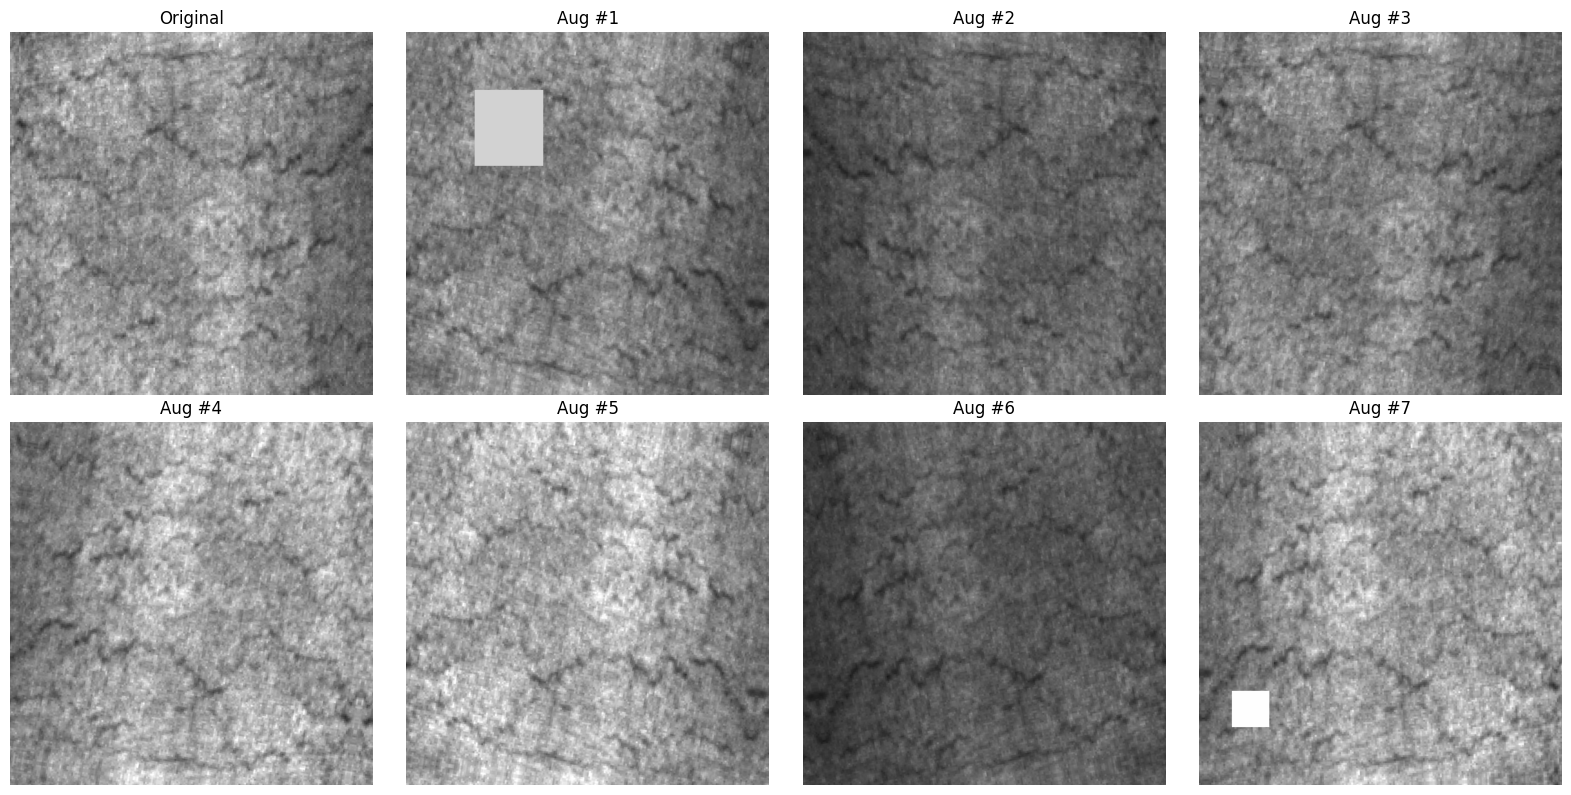

In [11]:
# Visual preview of the augmentations we'll apply
files = sorted(glob.glob(str(TRAIN_IMG_DIR / '*.jpg')) + glob.glob(str(TRAIN_IMG_DIR / '*.png')))
img = cv2.cvtColor(cv2.imread(files[0]), cv2.COLOR_BGR2RGB)
H, W = img.shape[:2]

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes[0, 0].imshow(img, cmap='gray' if IS_GRAYSCALE else None); axes[0, 0].set_title('Original'); axes[0, 0].axis('off')

for i, ax in enumerate(axes.flatten()[1:]):
    aug = img.copy().astype(np.float32)
    # Brightness only (grayscale)
    aug = np.clip(aug * np.random.uniform(0.6, 1.4), 0, 255).astype(np.uint8)
    # Small rotation
    angle = np.random.uniform(-10, 10)
    M = cv2.getRotationMatrix2D((W/2, H/2), angle, 1.0)
    aug = cv2.warpAffine(aug, M, (W, H), borderMode=cv2.BORDER_REFLECT)
    # Flips
    if random.random() < 0.5: aug = np.fliplr(aug)
    if random.random() < 0.5: aug = np.flipud(aug)
    # Random erasing (cutout)
    if random.random() < 0.4:
        eh, ew = int(H * np.random.uniform(0.1, 0.25)), int(W * np.random.uniform(0.1, 0.25))
        ey, ex = np.random.randint(0, H - eh), np.random.randint(0, W - ew)
        aug = aug.copy(); aug[ey:ey+eh, ex:ex+ew] = np.random.randint(0, 255)
    ax.imshow(aug, cmap='gray' if IS_GRAYSCALE else None); ax.set_title(f'Aug #{i+1}'); ax.axis('off')
plt.tight_layout(); plt.show()

## 4. Train YOLOv11s

Two stop conditions:
1. **Early stopping** via Ultralytics `patience` arg.
2. **Target mAP@50** custom callback — stops as soon as val `mAP@50 ≥ TARGET_MAP50`.

In [12]:
TARGET_MAP50 = 0.85   # NEU is harder than PCB (similar texture classes); 0.80-0.90 is a realistic target

def stop_on_target_map50(trainer):
    metrics = getattr(trainer, 'metrics', None) or {}
    map50 = metrics.get('metrics/mAP50(B)', metrics.get('metrics/mAP50', None))
    if map50 is not None and map50 >= TARGET_MAP50:
        print(f'\n>>> Target reached: mAP@50 = {map50:.4f} >= {TARGET_MAP50}. Stopping training.')
        trainer.stop = True

print(f'Will stop early once val mAP@50 >= {TARGET_MAP50}')

Will stop early once val mAP@50 >= 0.85


In [13]:
model = YOLO('yolo11s.pt')
model.add_callback('on_fit_epoch_end', stop_on_target_map50)

results = model.train(
    data=str(DATA_YAML),
    epochs=150,
    imgsz=640,                # Roboflow already resizes; 640 is the standard. Drop to 416 if you want to preserve native texture scale better.
    batch=16,                 # lower to 8 if OOM
    device=0 if torch.cuda.is_available() else 'cpu',
    optimizer='AdamW',
    lr0=0.001,
    lrf=0.01,
    weight_decay=0.0005,
    warmup_epochs=3,
    cos_lr=True,
    patience=25,              # NEU benefits from a bit more patience; texture classes are slow to separate
    close_mosaic=15,          # disable mosaic for the last 15 epochs
    amp=True,
    seed=42,
    project='runs/steel-defect',
    name='yolov11s_neu',
    exist_ok=True,
    pretrained=True,
    save=True,
    save_period=20,
    plots=True,
    verbose=True,
    **augmentation_cfg,
)

print('\nTraining complete.')

Ultralytics 8.4.60 🚀 Python-3.12.11 torch-2.8.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=15, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=steel-defect/data.yaml, degrees=10.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=150, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.5, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.0, hsv_s=0.0, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11s.pt, momentum=0.937, mosaic=0.5, multi_scale=0.0, name=yolov11s_neu, nbs=64, nms=False, opset=None, optimize=False, optimizer=AdamW, overlap_mask=True, patience=25, pers

     epoch     time  train/box_loss  train/cls_loss  train/dfl_loss  \
141    142  3295.49         1.10858         0.78039         1.41666   
142    143  3318.33         1.11779         0.79461         1.43283   
143    144  3341.16         1.12680         0.78623         1.41526   
144    145  3363.90         1.12582         0.79231         1.43016   
145    146  3386.78         1.11865         0.79001         1.41989   

     metrics/precision(B)  metrics/recall(B)  metrics/mAP50(B)  \
141               0.71753            0.69769           0.74990   
142               0.72680            0.68562           0.74713   
143               0.72908            0.69232           0.75158   
144               0.70716            0.71204           0.75020   
145               0.71088            0.70967           0.75396   

     metrics/mAP50-95(B)  val/box_loss  val/cls_loss  val/dfl_loss    lr/pg0  \
141              0.39037       1.69212       1.22794       1.73937  0.000019   
142             

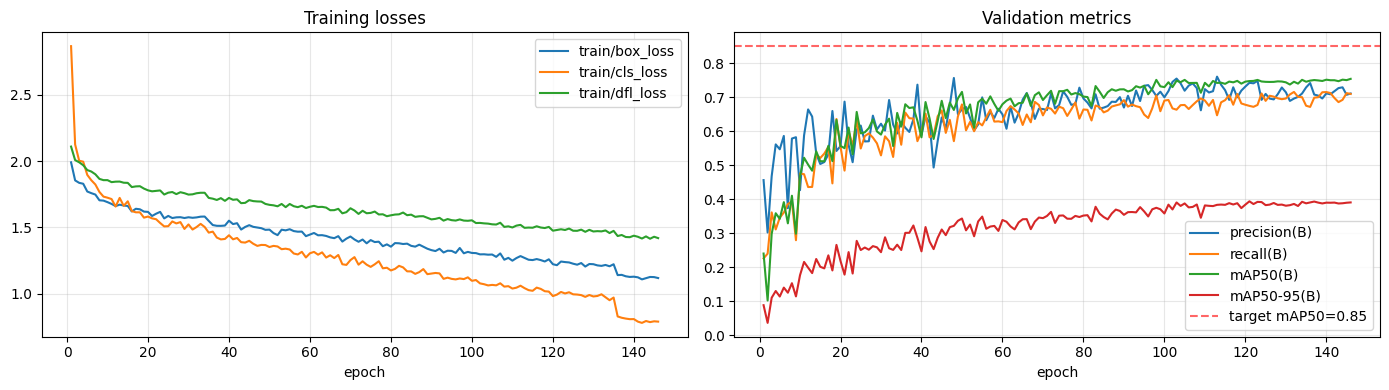

In [15]:
# Training curves
run_dir = Path('runs/detect/runs/steel-defect/yolov11s_neu')
csv_path = run_dir / 'results.csv'
if csv_path.exists():
    hist = pd.read_csv(csv_path); hist.columns = [c.strip() for c in hist.columns]
    print(hist.tail())
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    for col in ['train/box_loss', 'train/cls_loss', 'train/dfl_loss']:
        if col in hist.columns: axes[0].plot(hist['epoch'], hist[col], label=col)
    axes[0].set_title('Training losses'); axes[0].set_xlabel('epoch'); axes[0].legend(); axes[0].grid(alpha=0.3)
    for col in ['metrics/precision(B)', 'metrics/recall(B)', 'metrics/mAP50(B)', 'metrics/mAP50-95(B)']:
        if col in hist.columns: axes[1].plot(hist['epoch'], hist[col], label=col.split('/')[-1])
    axes[1].axhline(TARGET_MAP50, color='red', linestyle='--', alpha=0.6, label=f'target mAP50={TARGET_MAP50}')
    axes[1].set_title('Validation metrics'); axes[1].set_xlabel('epoch'); axes[1].legend(); axes[1].grid(alpha=0.3)
    plt.tight_layout(); plt.show()
else:
    print(f'No results.csv at {csv_path}')

## 5. Evaluation on the Test Set

In [16]:
best_weights = run_dir / 'weights' / 'best.pt'
print('Best weights:', best_weights, '| exists:', best_weights.exists())

best_model = YOLO(str(best_weights))
test_metrics = best_model.val(
    data=str(DATA_YAML), split='test',
    imgsz=640, batch=16,
    conf=0.001, iou=0.6,
    device=0 if torch.cuda.is_available() else 'cpu',
    plots=True, save_json=True,
)

print('\nTest set metrics:')
print(f'  mAP@50      = {test_metrics.box.map50:.4f}')
print(f'  mAP@50-95   = {test_metrics.box.map:.4f}')
print(f'  precision   = {test_metrics.box.mp:.4f}')
print(f'  recall      = {test_metrics.box.mr:.4f}')

print('\nPer-class mAP@50:')
for i, name in enumerate(CLASS_NAMES):
    try: print(f'  {name:>20}: {test_metrics.box.ap50[i]:.4f}')
    except Exception: pass

Best weights: runs/detect/runs/steel-defect/yolov11s_neu/weights/best.pt | exists: True
Ultralytics 8.4.60 🚀 Python-3.12.11 torch-2.8.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
YOLO11s summary (fused): 101 layers, 9,415,122 parameters, 0 gradients, 21.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 63.3±22.9 MB/s, size: 50.4 KB)
val: Scanning /teamspace/studios/this_studio/steel-defect/test/labels... 179 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 179/179 1.7Kit/s 0.1s<0.0s
val: New cache created: /teamspace/studios/this_studio/steel-defect/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 12/12 3.2it/s 3.7s0.2s
                   all        179        421      0.689      0.706      0.731       0.39
               crazing         35         70      0.446      0.386      0.388       0.12
             inclusion         50        135      0.763      0.726      0.785      0.409
               patches   

--- confusion_matrix.png ---


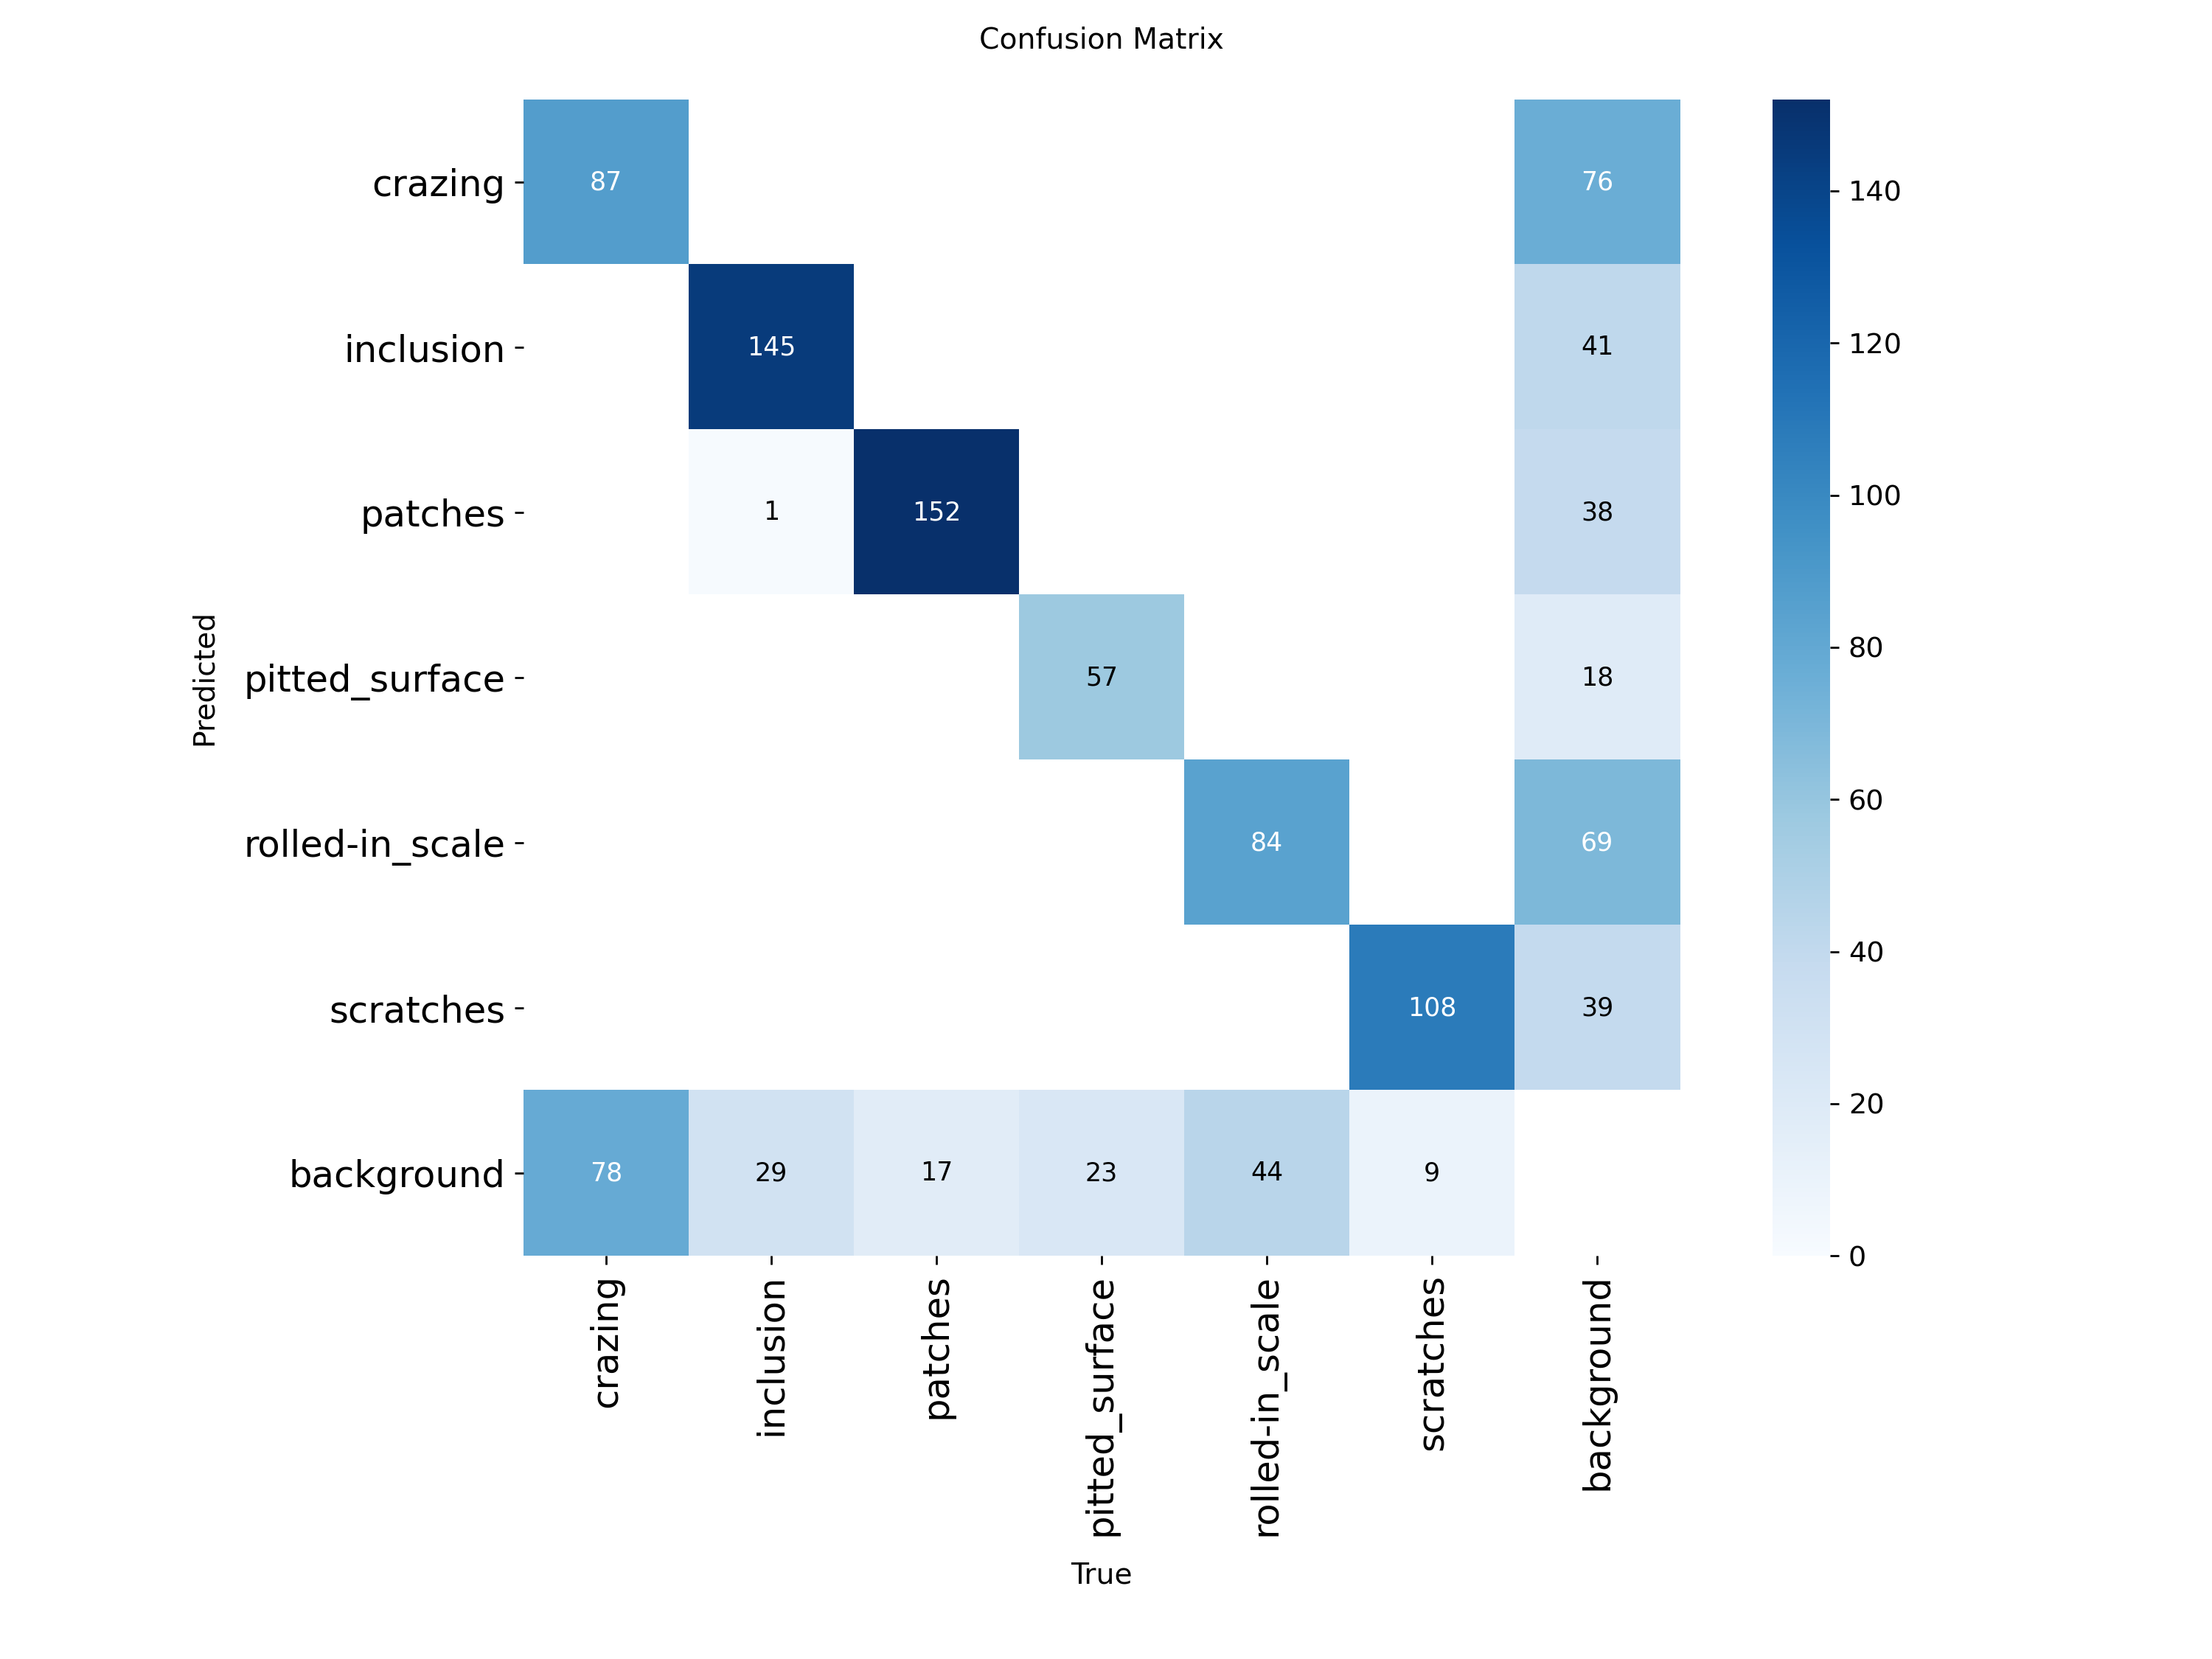

--- results.png ---


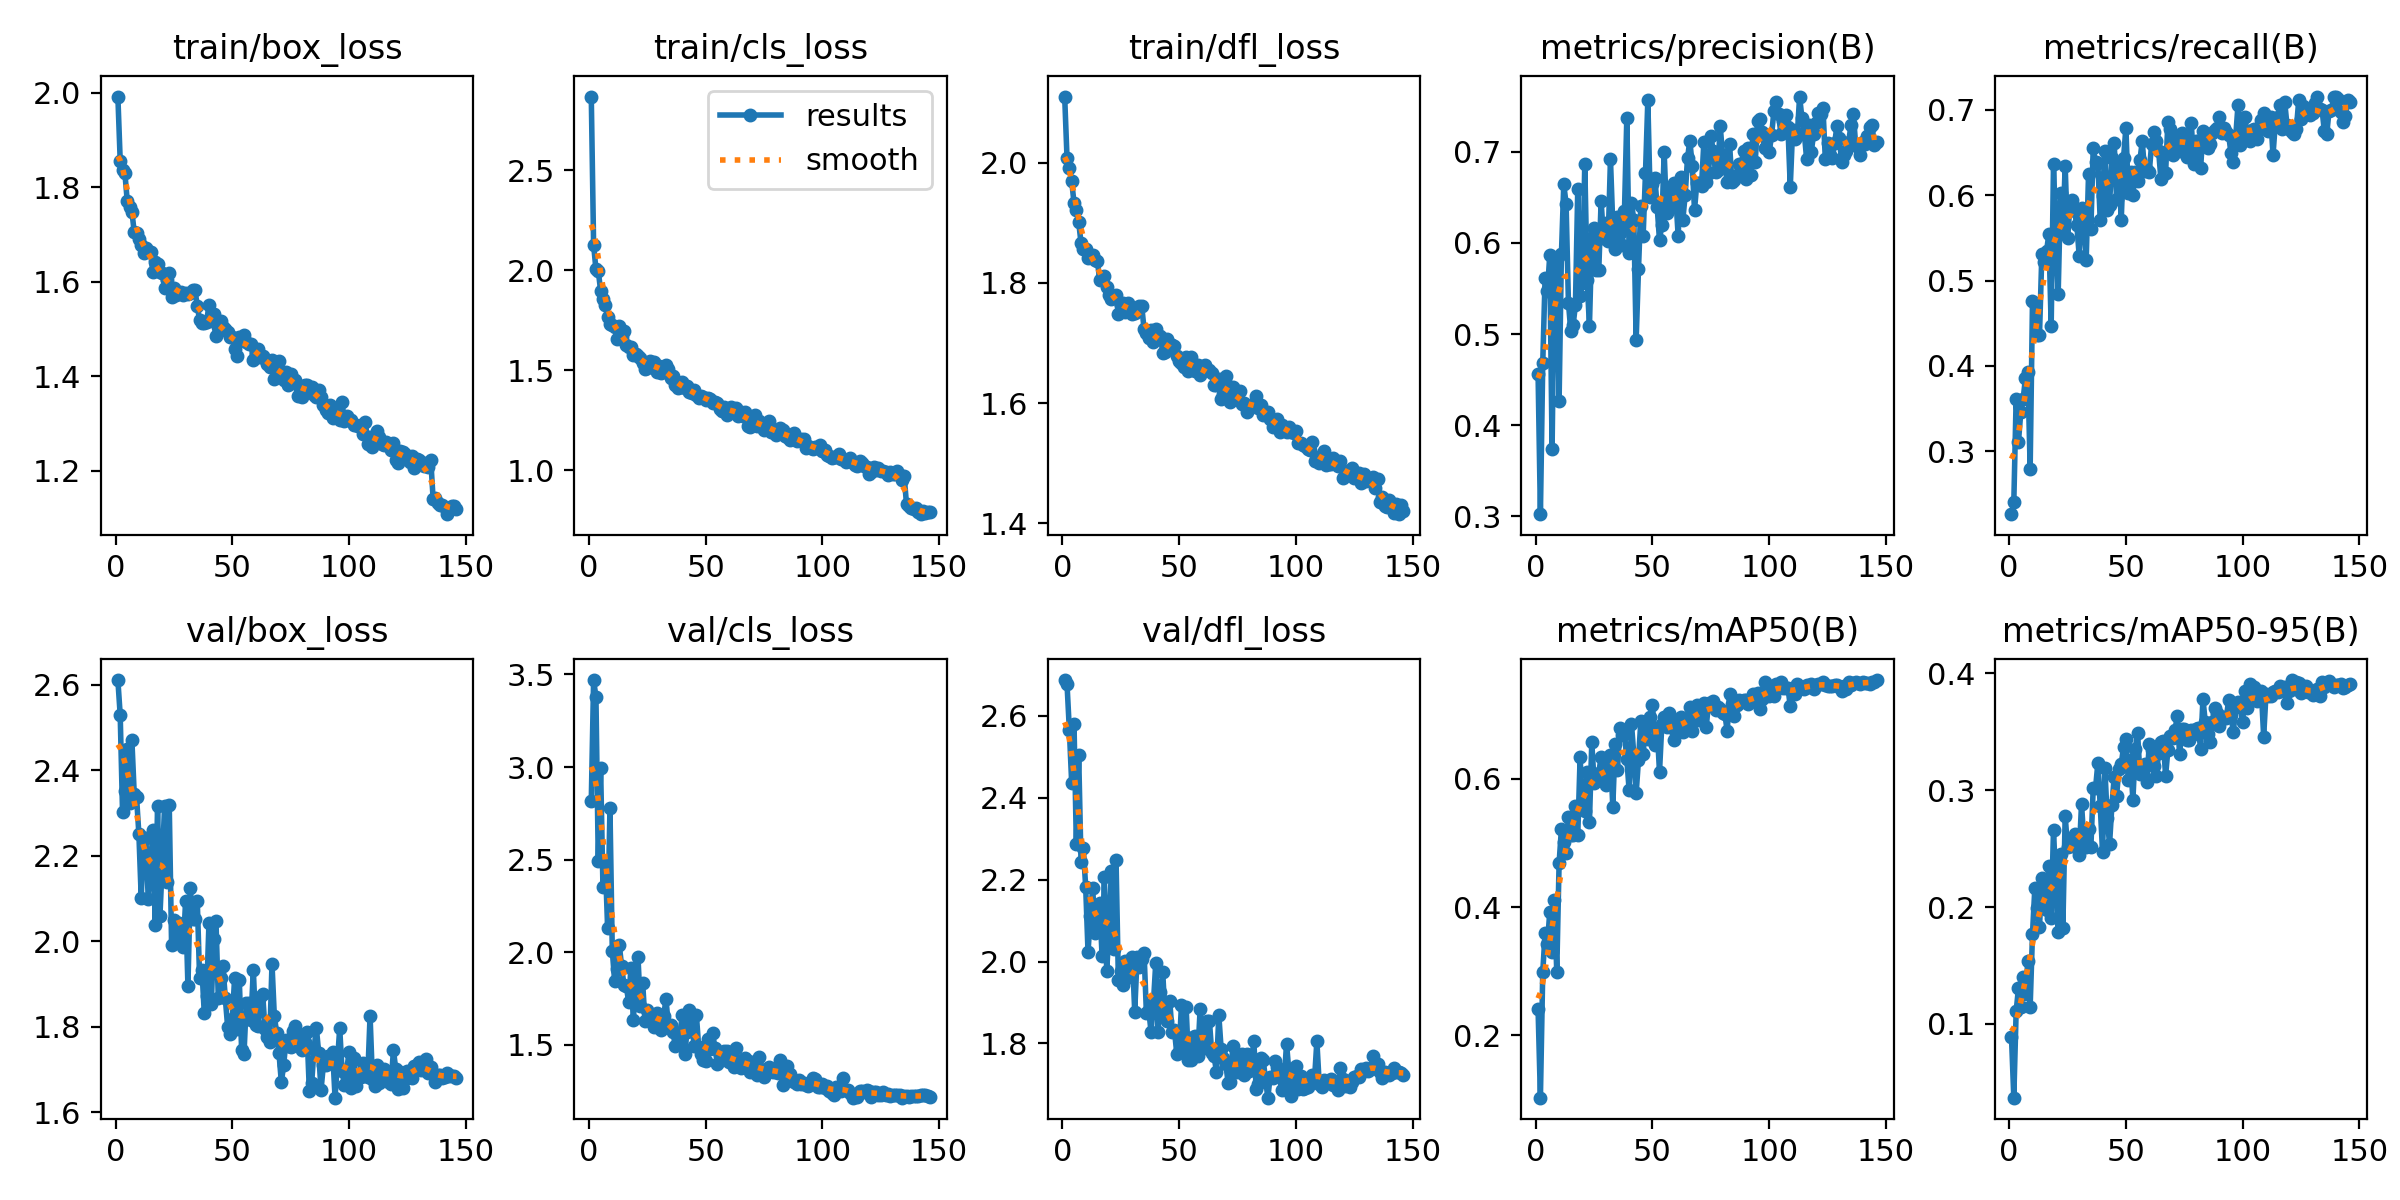

In [17]:
from IPython.display import Image, display
for fname in ['confusion_matrix.png', 'PR_curve.png', 'F1_curve.png', 'results.png']:
    p = run_dir / fname
    if p.exists():
        print(f'--- {fname} ---'); display(Image(str(p)))

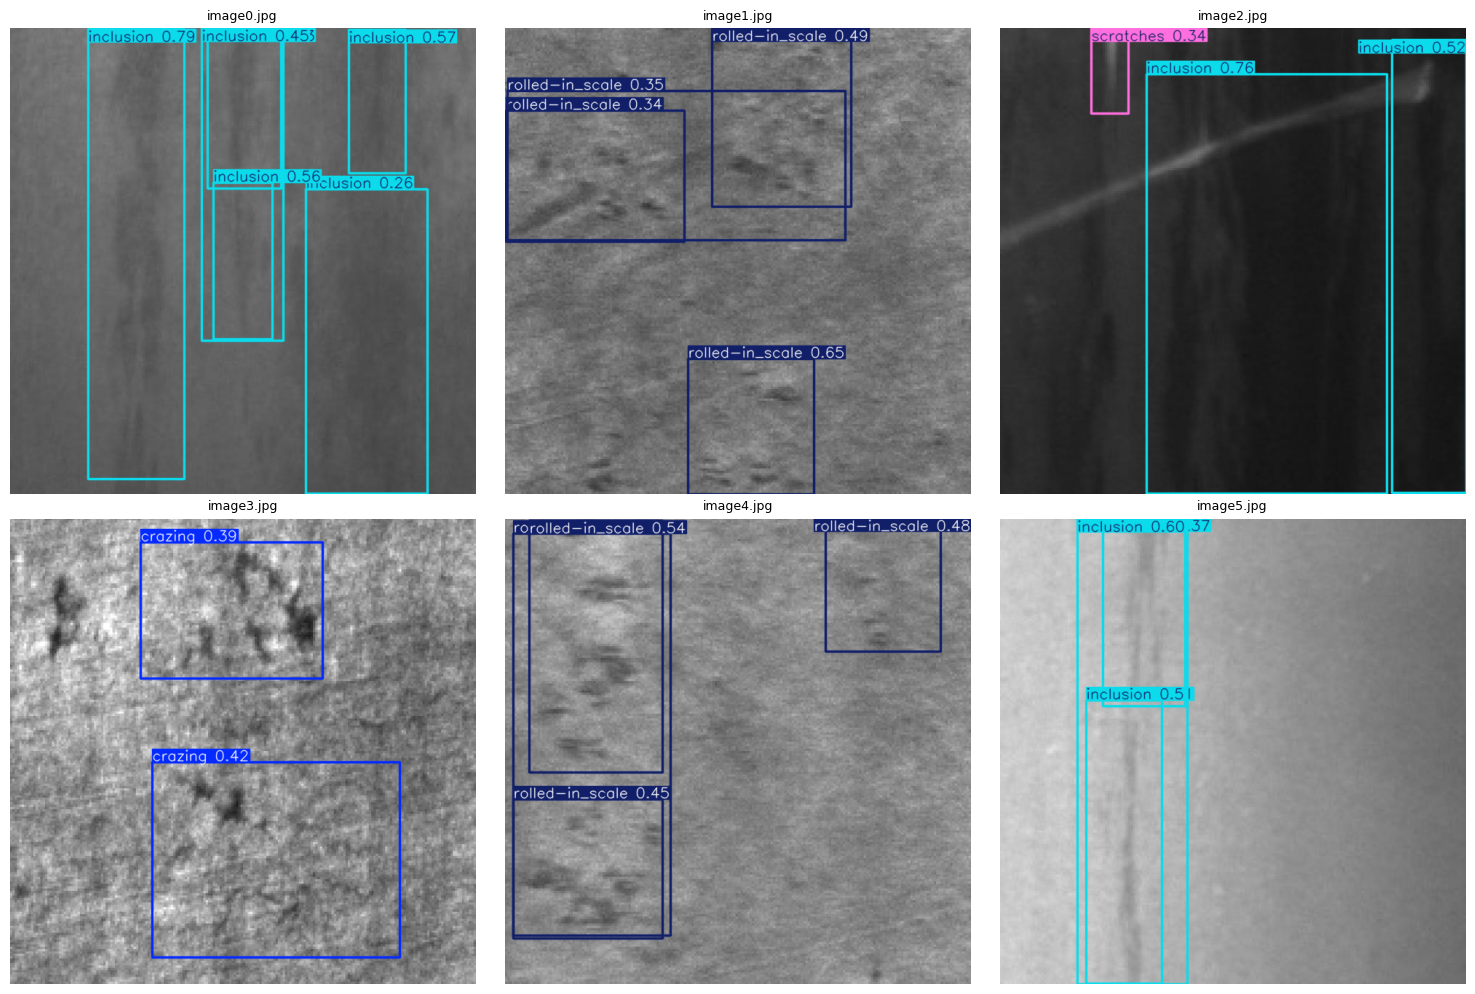

In [18]:
# Qualitative inference on test images
test_files = sorted(glob.glob(str(TEST_IMG_DIR / '*.jpg')) + glob.glob(str(TEST_IMG_DIR / '*.png')))
sample_test = random.sample(test_files, min(6, len(test_files)))
preds = best_model.predict(sample_test, imgsz=640, conf=0.25, iou=0.5, verbose=False)

cols = 3; rows = (len(preds) + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(cols*5, rows*5))
axes = np.array(axes).reshape(-1)
for ax, r in zip(axes, preds):
    plotted = r.plot()
    ax.imshow(cv2.cvtColor(plotted, cv2.COLOR_BGR2RGB))
    ax.set_title(Path(r.path).name, fontsize=9); ax.axis('off')
for ax in axes[len(preds):]: ax.axis('off')
plt.tight_layout(); plt.show()

## Done

Outputs are saved in `runs/steel-defect/yolov11s_neu/`. Use `best.pt`:
```python
from ultralytics import YOLO
model = YOLO('runs/steel-defect/yolov11s_neu/weights/best.pt')
model.predict('path/to/steel_image.jpg', save=True, conf=0.25)
```

**Tuning tips if a class underperforms (especially crazing / rolled-in scale / pitted_surface, which look alike):**
- Confirm class imbalance — if one class has many fewer instances, add `cls=0.7` (loss weight bump) or supplement with offline augmentation.
- Drop `imgsz` to 416 if the texture-similarity confusion stays high — preserves the native 200×200 texture scale better than upscaling to 640.
- Try `yolo11m.pt` for more capacity. NEU benefits more from model size than from heavier augmentation.
- If overfitting (train mAP >> val mAP), raise `erasing` to 0.5 and/or `weight_decay` to 0.001.
- If under-fitting after 100 epochs, lower `erasing` to 0.2 and raise `mosaic` to 0.7.